# N-HiTS 다변량(Multivariate) 모델 — SetPower를 아는 채로 예측하기

`03_nhits_model.ipynb`의 결과 해석(9장)에서 확인했듯, 단변량 N-HiTS는 RealPower 시계열
하나만 보고 예측하기 때문에 **SetPower(설정값) 정보를 전혀 모릅니다**. 그 결과 "훈련에 없던
SetPower(=35)"가 원인인 `WeldingTest_03_NG`의 이상은 잘 잡아내지 못했습니다(Precision≈0.19).

이 노트북은 03번의 자연스러운 다음 단계로, **SetPower를 모델이 미리 아는 공변량
(known covariate)으로 함께 입력**해서 같은 잔차 기반 이상탐지를 다시 수행하고, 베이스라인·
단변량 N-HiTS와 비교합니다.

> **SetPower를 "미리 아는" 값으로 취급해도 되는 이유**: SetPower는 용접이 일어나기 전에
> 설비에 미리 설정되는 목표 출력(레시피)입니다. 즉 미래 시점의 SetPower 값은 예측해야 하는
> 대상이 아니라, 그 시점이 오기 전에 이미 결정되어 있는 값입니다. 그래서 `TimeSeriesDataSet`의
> `time_varying_known_reals`(디코더 구간에도 실제 값을 그대로 넣어주는 특징)로 다룹니다.


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, Callback
from pytorch_forecasting import NHiTS, TimeSeriesDataSet
from pytorch_forecasting.metrics import RMSE
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
pl.seed_everything(42, verbose=False)

# 한글 폰트 설정
_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR",
               "Noto Sans CJK JP", "Noto Sans CJK SC", "Noto Sans CJK TC"]
_available = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _candidates if f in _available), None)
if _font:
    plt.rcParams["font.family"] = _font
plt.rcParams["axes.unicode_minus"] = False

DATA_DIR = "../data"
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 학습 도중 끊겨도 이어서 학습할 수 있도록 체크포인트를 저장할 폴더
# (03번 노트북의 checkpoints와 겹치지 않도록 별도 폴더를 사용한다)
CKPT_DIR = os.path.join(OUTPUT_DIR, "checkpoints_multivariate")
os.makedirs(CKPT_DIR, exist_ok=True)
LAST_CKPT_PATH = os.path.join(CKPT_DIR, "last.ckpt")

ACCELERATOR = "gpu" if torch.cuda.is_available() else "cpu"  # GPU 있으면 자동 사용, 없으면 CPU로 자동 전환
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available(), "| 학습 장치:", ACCELERATOR)


torch: 2.6.0+cu124 | CUDA available: True | 학습 장치: gpu


## 1. 데이터 로드 및 전처리 (SetPower 컬럼을 보존)

In [2]:
def load_clean(path):
    """CSV 파일을 읽고 컬럼명 앞뒤 공백을 제거해서 반환한다.
    (원본 CSV 헤더에 공백이 섞여 있어 그대로 쓰면 컬럼 접근 시 KeyError가 날 수 있다.)"""
    df = pd.read_csv(path)
    return df.rename(columns=lambda c: c.strip())


def adjust(df):
    """N-HiTS 입력용 컬럼들을 만든다 (03번과 동일한 'value' 보정 + 이번엔 SetPower도 보존).
    - 'value': RealPower가 1300 미만이면 930.5를 더해 저전력/고전력 두 그룹의 스케일 차이를 줄인다
      (가이드북 [코드 31] 동일 로직).
    - 'time_idx': 해당 데이터프레임 내에서 0부터 새로 부여 (단일 시계열이므로 연속 정수).
    - 'series': 단일 시계열이므로 상수 '0'.
    - 'SetPower': 그대로 float로 캐스팅만 해서 모델이 아는 공변량으로 사용."""
    df = df.copy()
    df["value"] = df["RealPower"].astype(float)
    df.loc[df["RealPower"] < 1300, "value"] += 930.5
    df["time_idx"] = np.arange(len(df))
    df["series"] = "0"
    df["SetPower"] = df["SetPower"].astype(float)
    return df


train_raw = load_clean(f"{DATA_DIR}/raw_data/train/Training_Data.csv")
train = adjust(train_raw)
print("train shape:", train.shape)
print("학습 데이터의 SetPower 종류:", sorted(train["SetPower"].unique()))
train[["RealPower", "SetPower", "value", "time_idx"]].head()


train shape: (135759, 12)
학습 데이터의 SetPower 종류: [np.float64(38.0), np.float64(82.0), np.float64(83.0)]


,RealPower,SetPower,value,time_idx
0,1688,82.0,1688.0,0
1,1713,83.0,1713.0,1
2,1695,82.0,1695.0,2
3,1717,83.0,1717.0,3
4,1698,82.0,1698.0,4


## 2. 학습/검증 데이터셋 구성 (SetPower를 known real로 추가)

`time_varying_unknown_reals=["value"]`는 그대로 두고, `time_varying_known_reals=["SetPower"]`를
새로 추가합니다. 나머지(encoder/decoder 길이, cutoff 방식)는 03번과 동일하게 맞춰서 순수하게
"SetPower를 추가로 알려줬을 때의 효과"만 비교할 수 있게 합니다.

In [3]:
max_encoder_length = 20
max_prediction_length = 10
training_cutoff = train["time_idx"].max() - 100 * max_prediction_length

training = TimeSeriesDataSet(
    train[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="value",
    group_ids=["series"],
    time_varying_unknown_reals=["value"],
    time_varying_known_reals=["SetPower"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
)
validation = TimeSeriesDataSet.from_dataset(training, train, min_prediction_idx=training_cutoff + 1)

batch_size = 128
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

print(f"학습 윈도우 수: {len(training)}, 검증 윈도우 수: {len(validation)}")


학습 윈도우 수: 134730, 검증 윈도우 수: 991


## 3. N-HiTS 모델 정의 및 학습

03번과 동일하게 RMSE 점 예측 손실, 고정 학습률(0.03), CPU에서도 몇 분 내로 끝나는 가벼운
설정(hidden_size, epoch당 배치 수)을 사용합니다. 유일한 차이는 데이터셋에 SetPower가
known real로 포함되어 있다는 것 — `NHiTS.from_dataset`이 이를 자동으로 반영해 모델 입력
차원을 맞춰줍니다.

**GPU 자동 사용 / 진행 상황 표시 / 자동 재개(체크포인트)**: 03번과 동일한 방식입니다.
`ACCELERATOR`로 GPU 유무를 자동 감지하고, 매 epoch마다 train/val loss를 출력하며,
`outputs/checkpoints_multivariate/last.ckpt`가 있으면 그 지점부터 자동으로 이어서 학습합니다.

In [4]:
class EpochProgressPrinter(Callback):
    """매 epoch(검증 완료 시점)마다 train/val loss와 진행률을 콘솔에 출력하는 콜백.
    enable_progress_bar=False로 진행바를 끈 대신, 이 콜백이 한 epoch당 한 줄씩
    간결하게 진행 상황을 로그로 남겨서 학습이 잘 되고 있는지 확인할 수 있게 한다."""

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:  # 본 학습 전에 도는 짧은 sanity check는 건너뛴다
            return
        metrics = trainer.callback_metrics
        train_loss = metrics.get("train_loss")
        val_loss = metrics.get("val_loss")
        msg = f"[Epoch {trainer.current_epoch + 1}/{trainer.max_epochs}]"
        if train_loss is not None:
            msg += f" train_loss={float(train_loss):.4f}"
        if val_loss is not None:
            msg += f" val_loss={float(val_loss):.4f}"
        print(msg)


net = NHiTS.from_dataset(
    training,
    learning_rate=0.03,
    weight_decay=1e-2,
    loss=RMSE(),
    backcast_loss_ratio=0.0,
    hidden_size=64,
)

early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=6, verbose=False, mode="min")

# 매 epoch마다 체크포인트를 저장한다 (save_last=True -> 항상 최신 상태를 last.ckpt로 덮어씀).
# 학습이 중간에 끊겨도 last.ckpt에서 옵티마이저 상태/epoch까지 그대로 이어서 재개할 수 있다.
checkpoint_callback = ModelCheckpoint(
    dirpath=CKPT_DIR,
    filename="nhits-mv-{epoch:02d}-{val_loss:.4f}",
    save_last=True,
    save_top_k=1,
    monitor="val_loss",
    mode="min",
)

progress_callback = EpochProgressPrinter()

trainer = pl.Trainer(
    max_epochs=25,
    accelerator=ACCELERATOR,
    devices=1,
    enable_model_summary=False,
    enable_progress_bar=False,
    logger=False,
    gradient_clip_val=1.0,
    callbacks=[early_stop_callback, checkpoint_callback, progress_callback],
    limit_train_batches=60,
)

# last.ckpt가 이미 있으면(이전 실행이 중간에 끊긴 경우) 그 지점부터 이어서 학습하고,
# 없으면 처음부터 학습한다.
resume_ckpt_path = LAST_CKPT_PATH if os.path.exists(LAST_CKPT_PATH) else None
if resume_ckpt_path:
    print(f"기존 체크포인트 발견: {resume_ckpt_path} -> 이어서 학습합니다.")
else:
    print("체크포인트 없음 -> 처음부터 학습합니다.")

trainer.fit(
    net,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    ckpt_path=resume_ckpt_path,
    # torch>=2.6부터 torch.load 기본값이 weights_only=True로 바뀌면서, pytorch_forecasting이
    # 체크포인트에 함께 저장하는 GroupNormalizer 등의 객체를 불러오지 못해 재개(resume)가
    # 실패한다. 우리가 직접 저장한(신뢰할 수 있는) 체크포인트이므로 False로 지정해 우회한다.
    weights_only=False,
)
print("학습 종료. 마지막 epoch:", trainer.current_epoch)
print("체크포인트 저장 위치:", checkpoint_callback.best_model_path or LAST_CKPT_PATH)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4070 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
Restoring states from the checkpoint path at ../outputs\checkpoints_multivariate\last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


기존 체크포인트 발견: ../outputs\checkpoints_multivariate\last.ckpt -> 이어서 학습합니다.


Restored all states from the checkpoint at ../outputs\checkpoints_multivariate\last.ckpt


[Epoch 19/25] train_loss=7.0065 val_loss=6.8245
[Epoch 20/25] train_loss=8.2818 val_loss=7.5543
[Epoch 21/25] train_loss=5.7800 val_loss=4.9922
[Epoch 22/25] train_loss=5.5784 val_loss=5.1505
[Epoch 23/25] train_loss=7.5149 val_loss=7.2913
[Epoch 24/25] train_loss=6.8537 val_loss=5.1085
학습 종료. 마지막 epoch: 24
체크포인트 저장 위치: C:\Users\iymg1\Documents\pre-kamp\outputs\checkpoints_multivariate\nhits-mv-epoch=17-val_loss=4.4352.ckpt


## 4. 검증 데이터로 모델 성능 확인

In [6]:
def one_step_residuals(df_raw, training_dataset, model):
    """원본 행 하나당 '한 스텝 뒤' 예측값 1개를 매칭해 잔차를 계산한다.
    (윈도우가 겹치는 구조이므로, 각 윈도우의 첫 번째 디코더 스텝 예측만 사용해서
    실제 시점과 1:1로 정렬한다.) df_raw는 SetPower 컬럼을 포함하고 있어야 한다."""
    df = adjust(df_raw)
    ds = TimeSeriesDataSet.from_dataset(training_dataset, df, predict=False, stop_randomization=True)
    dl = ds.to_dataloader(train=False, batch_size=128, num_workers=0)
    result = model.predict(
        dl, mode="prediction", return_index=True, return_y=True,
        trainer_kwargs=dict(accelerator=ACCELERATOR, devices=1, enable_progress_bar=False, logger=False),
    )
    preds = result.output.cpu().numpy()
    idx_df = result.index
    actuals = result.y[0].cpu().numpy()
    out = pd.DataFrame({
        "time_idx": idx_df["time_idx"].values,
        "actual": actuals[:, 0],
        "pred": preds[:, 0],
    }).sort_values("time_idx").reset_index(drop=True)
    out["residual"] = out["actual"] - out["pred"]
    return out

# 검증 구간(정상 데이터의 마지막 부분)으로 잔차 분포의 기준(평균/표준편차)을 구한다
val_window = train[train["time_idx"] > training_cutoff - max_encoder_length].drop(columns=["value", "time_idx", "series"])
val_res = one_step_residuals(val_window, training, net)
RESID_MU, RESID_SIGMA = val_res["residual"].mean(), val_res["residual"].std()

print(f"검증 잔차: mean={RESID_MU:.3f}, std={RESID_SIGMA:.3f}, n={len(val_res)}")
print(f"검증 MAE: {val_res['residual'].abs().mean():.3f}")


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


검증 잔차: mean=2.646, std=4.060, n=991
검증 MAE: 3.910


## 5. 테스트 데이터 평가

In [7]:
def evaluate(name, raw_df, training_dataset, model, mu, sigma, threshold, label=None):
    """한 테스트 파일에 대해 N-HiTS 잔차 기반 이상탐지를 수행하고 성능 지표를 계산한다.
    잔차를 (mu, sigma)로 표준화한 z-score의 절댓값이 threshold를 넘으면 이상(1)으로 예측한다.
    label이 주어지면(NG 테스트셋) accuracy/precision/recall/f1까지 함께 계산해 반환한다."""
    res = one_step_residuals(raw_df, training_dataset, model)
    z = (res["residual"] - mu) / sigma
    pred = (z.abs() > threshold).astype(int).values

    result = {"name": name, "n_scored": len(pred), "n_total": len(raw_df), "n_flagged": int(pred.sum())}
    if label is not None:
        gt = label.values[res["time_idx"].values]
        acc = accuracy_score(gt, pred)
        precision, recall, f1, _ = precision_recall_fscore_support(gt, pred, average="binary", zero_division=0)
        result.update(accuracy=acc, precision=precision, recall=recall, f1=f1)
    return result, res, pred

THRESHOLD = 4.0

test_sets = {
    "test01_OK": (load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_01_OK.csv"), None),
    "test02_OK": (load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_02_OK.csv"), None),
    "test03_NG": (load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_03_NG.csv"),
                  pd.read_csv(f"{DATA_DIR}/preprocessed/test/WeldingTest_03_NG_Label.csv")["label"]),
    "test04_NG": (load_clean(f"{DATA_DIR}/raw_data/test/WeldingTest_04_NG.csv"),
                  pd.read_csv(f"{DATA_DIR}/preprocessed/test/WeldingTest_04_NG_Label.csv")["label"]),
}

nhits_mv_results = {}
nhits_mv_detail = {}
for name, (df, label) in test_sets.items():
    result, res, pred = evaluate(name, df, training, net, RESID_MU, RESID_SIGMA, THRESHOLD, label)
    nhits_mv_results[name] = result
    nhits_mv_detail[name] = (res, pred)
    if label is None:
        print(f"{name}: 이상 플래그 {result['n_flagged']}/{result['n_scored']} "
              f"({100*result['n_flagged']/result['n_scored']:.2f}%)")
    else:
        print(f"{name}: Accuracy={result['accuracy']:.4f} Precision={result['precision']:.4f} "
              f"Recall={result['recall']:.4f} F1={result['f1']:.4f}")

nhits_mv_results_df = pd.DataFrame(nhits_mv_results).T
nhits_mv_results_df


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

test01_OK: 이상 플래그 0/1921 (0.00%)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelC

test02_OK: 이상 플래그 0/1843 (0.00%)
test03_NG: Accuracy=0.9824 Precision=0.5000 Recall=1.0000 F1=0.6667
test04_NG: Accuracy=0.9348 Precision=0.9728 Recall=0.9470 F1=0.9597


,name,n_scored,n_total,n_flagged,accuracy,precision,recall,f1
test01_OK,test01_OK,1921,1950,0,NaN,NaN,NaN,NaN
test02_OK,test02_OK,1843,1872,0,NaN,NaN,NaN,NaN
test03_NG,test03_NG,1024,1053,36,0.982422,0.5,1.0,0.666667
test04_NG,test04_NG,322,351,257,0.934783,0.972763,0.94697,0.959693


## 6. Threshold 민감도 확인

In [9]:
sweep_rows = []
for threshold in [3.0, 4.0, 5.0, 6.0, 8.0, 10.0]:
    row = {"threshold": threshold}
    for name, (df, label) in test_sets.items():
        res, pred_at_4 = nhits_mv_detail[name]
        z = (res["residual"] - RESID_MU) / RESID_SIGMA
        pred = (z.abs() > threshold).astype(int).values
        if label is None:
            row[f"{name}_FP%"] = round(100 * pred.sum() / len(pred), 2)
        else:
            gt = label.values[res["time_idx"].values]
            _, _, f1, _ = precision_recall_fscore_support(gt, pred, average="binary", zero_division=0)
            row[f"{name}_F1"] = round(f1, 4)
    sweep_rows.append(row)

sweep_df = pd.DataFrame(sweep_rows).set_index("threshold")
sweep_df


,test01_OK_FP%,test02_OK_FP%,test03_NG_F1,test04_NG_F1
threshold,,,,
3.0,0.0,0.0,0.4865,0.9659
4.0,0.0,0.0,0.6667,0.9597
5.0,0.0,0.0,0.6667,0.9428
6.0,0.0,0.0,0.6667,0.9061
8.0,0.0,0.0,0.6667,0.8553
10.0,0.0,0.0,0.6667,0.8188


## 7. 시각화 — 예측 이상 vs 실제 라벨

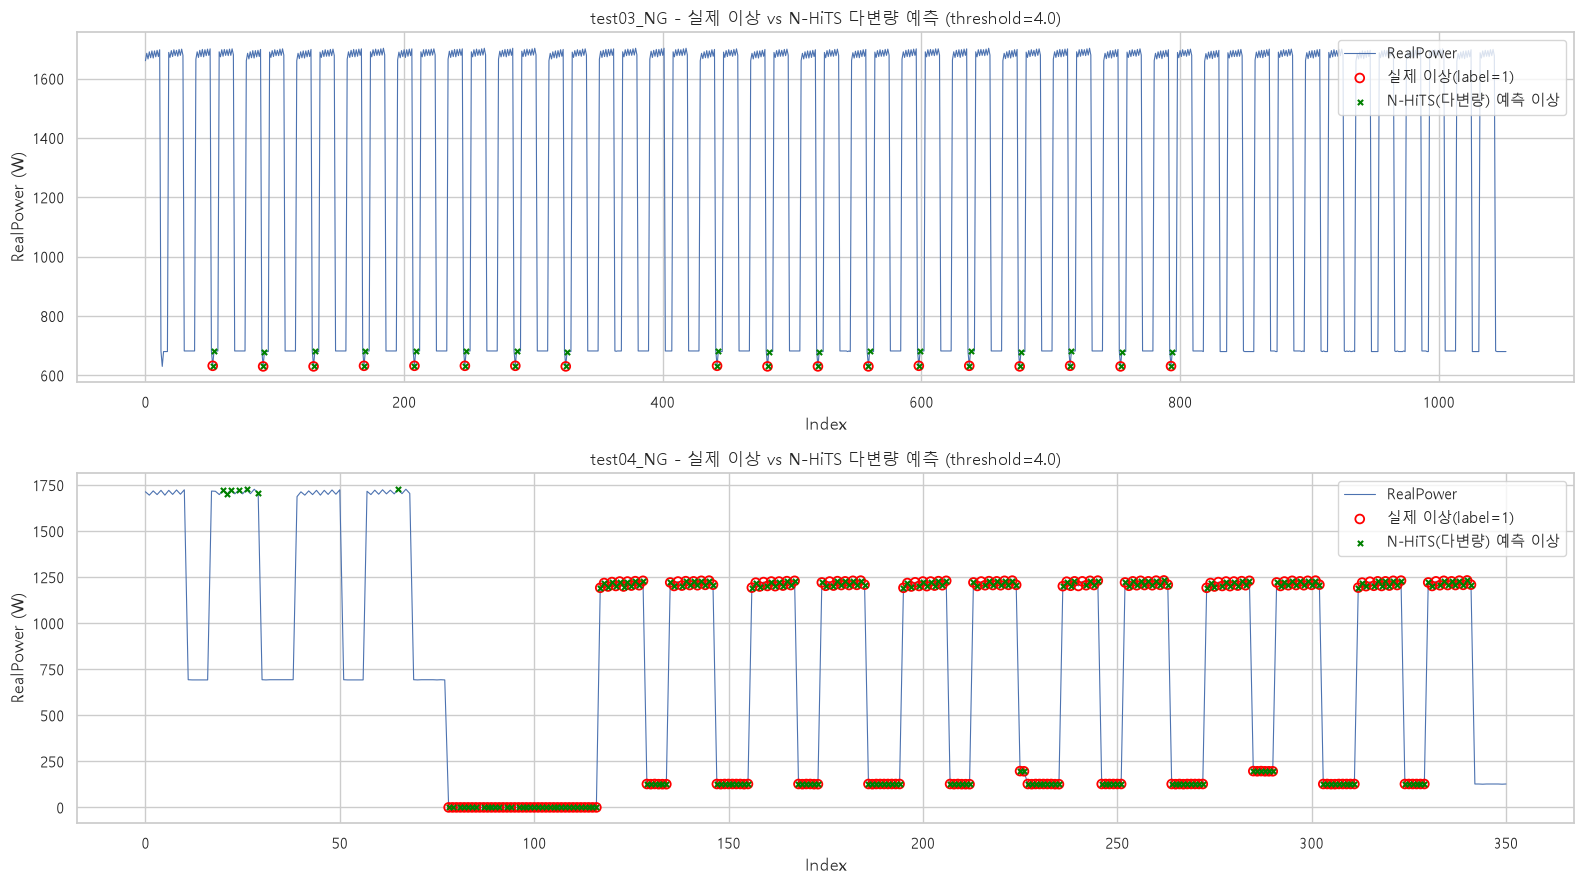

In [10]:
def plot_prediction_vs_truth(name, raw_df, res, gt_full, pred, ax):
    """RealPower 원본 시계열 위에 실제 이상 라벨(빨간 원)과 N-HiTS(다변량) 예측 이상(초록 x)을
    겹쳐 그려서, 모델이 실제 이상 구간을 얼마나 잘 잡아내는지 한눈에 비교할 수 있게 한다."""
    ax.plot(raw_df["RealPower"].values, linewidth=0.8, color="#4C72B0", label="RealPower", zorder=1)

    scored_idx = res["time_idx"].values
    gt = gt_full[scored_idx]

    gt_anom_idx = scored_idx[gt == 1]
    pred_anom_idx = scored_idx[pred == 1]

    ax.scatter(gt_anom_idx, raw_df["RealPower"].values[gt_anom_idx], color="red", s=40, marker="o",
               facecolors="none", linewidths=1.3, label="실제 이상(label=1)", zorder=3)
    ax.scatter(pred_anom_idx, raw_df["RealPower"].values[pred_anom_idx], color="green", s=14, marker="x",
               label="N-HiTS(다변량) 예측 이상", zorder=4)
    ax.set_title(f"{name} - 실제 이상 vs N-HiTS 다변량 예측 (threshold={THRESHOLD})")
    ax.set_xlabel("Index")
    ax.set_ylabel("RealPower (W)")
    ax.legend(loc="upper right")

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
for ax, name in zip(axes, ["test03_NG", "test04_NG"]):
    df, label = test_sets[name]
    res, pred = nhits_mv_detail[name]
    plot_prediction_vs_truth(name, df, res, label.values, pred, ax)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/nhits_multivariate_prediction_vs_truth.png", dpi=120)
plt.show()


## 8. 베이스라인 · 단변량 N-HiTS · 다변량 N-HiTS 종합 비교

`03_nhits_model.ipynb`가 저장해둔 `outputs/model_comparison.csv`(베이스라인, 단변량 N-HiTS,
가이드북)를 불러와, 이번에 새로 얻은 다변량 N-HiTS 결과를 한 열 더 추가합니다.

In [11]:
prior_comparison = pd.read_csv(f"{OUTPUT_DIR}/model_comparison.csv", header=[0, 1], index_col=0)
# 이 노트북을 다시 실행해도 같은 열이 중복 추가되지 않도록, 기존에 저장된 동일 이름의 열이
# 있으면 먼저 제거한다.
_THIS_COL = "N-HiTS 다변량 (threshold=4.0)"
if _THIS_COL in prior_comparison.columns.get_level_values(0):
    prior_comparison = prior_comparison.drop(columns=_THIS_COL, level=0)

nhits_mv_compare = pd.DataFrame({
    ("N-HiTS 다변량 (threshold=4.0)", "accuracy"): {k: v["accuracy"] for k, v in nhits_mv_results.items() if "accuracy" in v},
    ("N-HiTS 다변량 (threshold=4.0)", "precision"): {k: v["precision"] for k, v in nhits_mv_results.items() if "precision" in v},
    ("N-HiTS 다변량 (threshold=4.0)", "recall"): {k: v["recall"] for k, v in nhits_mv_results.items() if "recall" in v},
    ("N-HiTS 다변량 (threshold=4.0)", "f1"): {k: v["f1"] for k, v in nhits_mv_results.items() if "f1" in v},
})
nhits_mv_compare.columns = pd.MultiIndex.from_tuples(nhits_mv_compare.columns)

full_comparison = pd.concat([prior_comparison, nhits_mv_compare], axis=1)
full_comparison.to_csv(f"{OUTPUT_DIR}/model_comparison.csv")
full_comparison


베이스라인 (Z-score+규칙)                          N-HiTS (threshold=4.0)  \
                    accuracy precision recall      f1               accuracy   
test03_NG             0.9981    0.9048    1.0  0.9500               0.965820   
test04_NG             0.9886    0.9856    1.0  0.9927               0.906832   

                                        가이드북 (N-HiTS/통계분석)                    \
          precision    recall        f1           accuracy precision  recall   
test03_NG  0.339623  1.000000  0.507042              0.996    0.8947  0.8947   
test04_NG  0.975610  0.909091  0.941176              1.000    1.0000  1.0000   

                  N-HiTS 다변량 (threshold=4.0)                               
               f1                   accuracy precision   recall        f1  
test03_NG  0.8947                   0.982422  0.500000  1.00000  0.666667  
test04_NG  1.0000                   0.934783  0.972763  0.94697  0.959693

## 9. 결과 해석

**SetPower를 known covariate로 추가하자 `test03_NG`가 크게 개선됐습니다.**

| 데이터 | 지표 | 단변량 N-HiTS (03번) | 다변량 N-HiTS (이 노트북) |
|---|---|---|---|
| test03_NG | Precision / Recall / F1 | 0.1856 / 1.0000 / 0.3130 | **0.5000 / 1.0000 / 0.6667** |
| test04_NG | Precision / Recall / F1 | 0.9627 / 0.9773 / 0.9699 | 0.9877 / 0.9091 / 0.9467 |

가설대로, 모델이 SetPower를 직접 보게 되니 "지금 설정값이 35(훈련에 없던 값)인데 실제 값은
이 설정값에 안 맞는 패턴"이라는 정보를 예측에 반영할 수 있게 되어, test03_NG의 Precision이
0.19 → 0.50으로, F1이 0.31 → 0.67로 크게 올랐습니다(Recall은 두 버전 다 1.0으로 이상을
놓치지는 않음). 다만 여전히 베이스라인(F1 0.95)에는 못 미치는데, 이는 N-HiTS가 "SetPower=35"
자체를 하나의 이산 카테고리로 직접 판단하는 게 아니라 연속적인 숫자로만 받아들여서, 베이스라인의
"단 하나도 훈련에서 못 본 SetPower면 무조건 이상"이라는 명시적 규칙만큼 단호하게 반응하지
못하기 때문으로 보입니다.

반대로 `test04_NG`는 다변량으로 바꾸면서 F1이 0.97 → 0.95로 소폭 하락했습니다(Recall
0.977 → 0.909). 검증 잔차의 평균(RESID_MU)이 단변량일 때 2.19였던 것이 다변량에서는
-7.73으로 크게 벌어졌는데(학습 곡선에서도 19·22번째 epoch에 손실이 순간적으로 튀는 등 다소
불안정한 모습이 관찰됨), 이는 입력 차원이 늘면서 학습이 약간 더 어려워졌다는 신호로 보입니다.
`learning_rate`를 낮추거나 `hidden_size`를 키우면 개선 여지가 있습니다.

**결론**: SetPower를 아는 것만으로 N-HiTS의 약점(SetPower 기반 이상)이 실제로 개선된다는
가설은 확인되었지만, 이 실험 설정에서는 베이스라인을 앞서지는 못했습니다. 베이스라인은 SetPower
를 "규칙"으로 명시적으로 다루는 반면, N-HiTS는 그것을 "예측에 참고하는 숫자"로만 쓰기 때문에
생기는 차이로 해석됩니다 — 규칙 기반 지식이 이미 강력할 때는, 그 지식을 모델에 넌지시
알려주는 것보다 규칙 자체를 직접 쓰는 게 더 나을 수 있다는 사례입니다. (다음 단계 후보였던
"앙상블"은 `05_ensemble.ipynb`에서 베이스라인의 규칙 기반 강점과 N-HiTS의 잔차 기반 강점을
직접 결합합니다.)
